# 🤖 Modelagem para Detecção de Fraudes

## Treinamento, avaliação e comparação dos modelos

**Autor:** Lucas Frota

### Objetivos

- Preparar os dados para Machine Learning
- Preservar o desbalanceamento na divisão entre treino e teste
- Treinar diferentes modelos de classificação
- Comparar Precision, Recall, F1-score, ROC-AUC e PR-AUC
- Avaliar diferentes thresholds
- Selecionar o modelo mais adequado para o problema

In [35]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [36]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: c:\Users\Pichau\Documents\Projetos\credit-card-fraud-detection


In [37]:
from src.data_loader import get_dataset
from src.evaluation import create_metrics_table, evaluate_model
from src.models import (
    train_logistic_regression,
    train_random_forest,
    train_xgboost,
)
from src.preprocessing import (
    prepare_data,
    split_features_target,
    split_train_test,
)
from src.threshold import evaluate_thresholds

## 1. Carregamento dos dados

O dataset é carregado por meio da função reutilizável criada em `src/data_loader.py`.

In [38]:
df = get_dataset()

print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

df.head()

Dataset já encontrado em: C:\Users\Pichau\Documents\Projetos\credit-card-fraud-detection\data\raw\creditcard.csv
Quantidade de registros: 284807
Quantidade de colunas: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Preparação dos dados

Durante o Feature Engineering:

- a coluna `Time` é transformada na variável `Hour`;
- a coluna `Amount` recebe uma transformação logarítmica;
- as colunas originais `Time` e `Amount` são removidas;
- a variável alvo permanece na coluna `Class`.

In [39]:
df_model = prepare_data(df)

df_model.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.000000,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.000000,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.000278,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.000278,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.000556,4.262539


In [40]:
df_model.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour',
       'Amount_log'],
      dtype='str')

## 3. Separação entre atributos e variável-alvo

- `X` contém as informações usadas pelos modelos.
- `y` contém a classe real da transação.

A classe `0` representa uma transação legítima e a classe `1` representa uma fraude.

In [41]:
X, y = split_features_target(df_model)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")

Formato de X: (284807, 30)
Formato de y: (284807,)


## 4. Divisão entre treino e teste

Foi utilizada uma divisão estratificada para preservar a proporção de fraudes nos conjuntos de treino e teste.

In [42]:
X_train, X_test, y_train, y_test = split_train_test(X, y)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (199364, 30)
Teste:  (85443, 30)


In [43]:
distribuicao = pd.DataFrame({
    "Treino": y_train.value_counts(normalize=True),
    "Teste": y_test.value_counts(normalize=True),
})

distribuicao

,Treino,Teste
Class,,
0,0.998275,0.998268
1,0.001725,0.001732


## 5. Treinamento dos modelos

Foram comparados três algoritmos:

1. Regressão Logística
2. Random Forest
3. XGBoost

Os modelos utilizam estratégias específicas para lidar com o forte desbalanceamento das classes.

In [44]:
logistic_model = train_logistic_regression(
    X_train,
    y_train,
)

random_forest_model = train_random_forest(
    X_train,
    y_train,
)

xgboost_model = train_xgboost(
    X_train,
    y_train,
)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


In [45]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model,
}

metrics_results = []
probabilities = {}
confusion_matrices = {}

for model_name, model in models.items():
    metrics, predictions, model_probabilities, matrix = evaluate_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name,
    )

    metrics_results.append(metrics)
    probabilities[model_name] = model_probabilities
    confusion_matrices[model_name] = matrix

In [46]:
metrics_table = create_metrics_table(metrics_results)

metrics_table

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.976967,0.062500,0.878378,0.116697,0.970154,0.698969
1,XGBoost,0.998677,0.583732,0.824324,0.683473,0.967271,0.806570
2,Random Forest,0.999146,0.732919,0.797297,0.763754,0.977280,0.776408


## 6. Comparação das métricas

A acurácia não será considerada isoladamente, pois mais de 99% das transações pertencem à classe legítima.

As principais métricas são:

- **Recall:** proporção de fraudes reais encontradas;
- **Precision:** proporção de alertas que realmente eram fraudes;
- **F1-score:** equilíbrio entre Precision e Recall;
- **PR-AUC:** desempenho entre Precision e Recall em diferentes thresholds;
- **ROC-AUC:** capacidade geral de separação das classes.

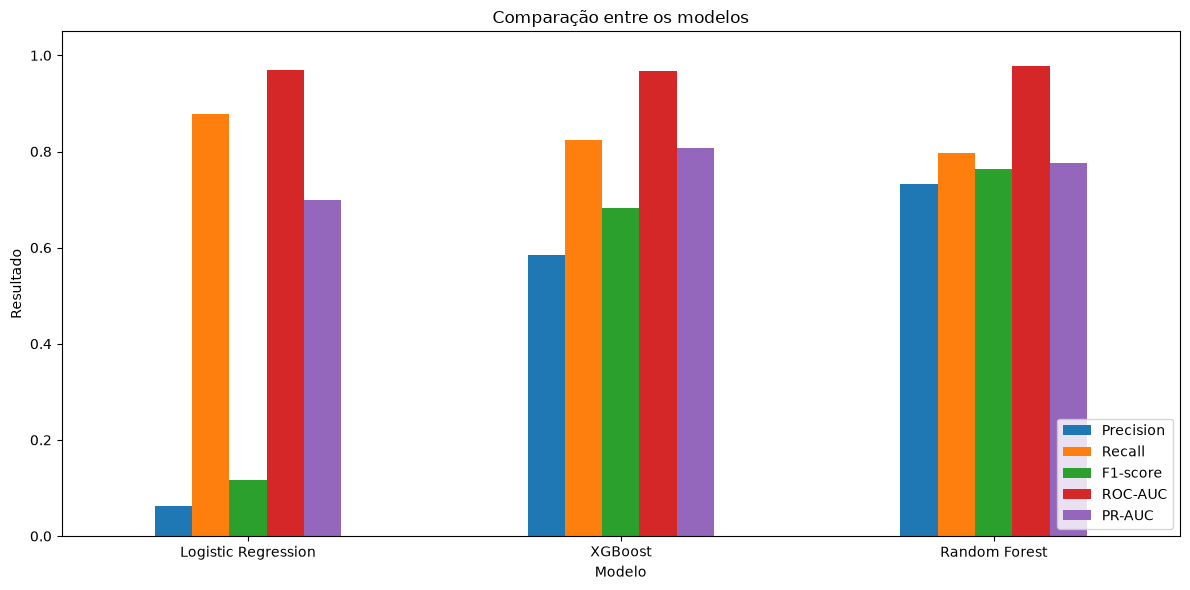

In [47]:
plot_data = metrics_table.set_index("Model")[
    ["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
]

plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("Comparação entre os modelos")
plt.xlabel("Modelo")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Matrizes de confusão

As matrizes permitem visualizar:

- verdadeiros negativos;
- falsos positivos;
- falsos negativos;
- verdadeiros positivos.

Em detecção de fraude, os falsos negativos merecem atenção especial, pois representam fraudes classificadas como legítimas.

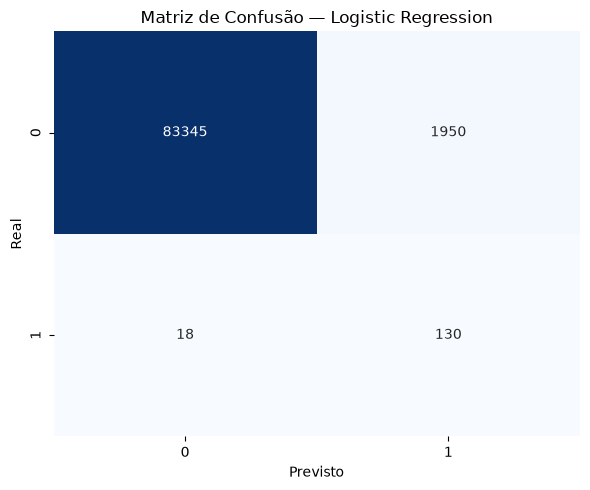

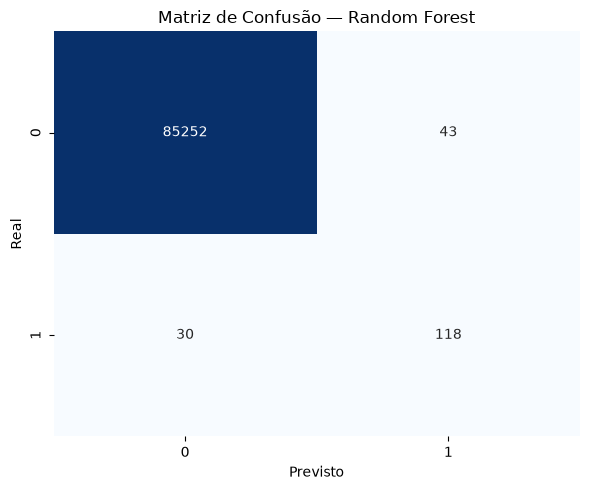

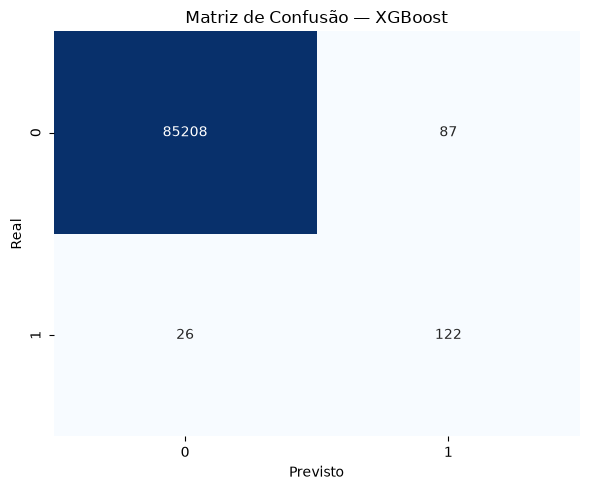

In [48]:
for model_name, matrix in confusion_matrices.items():
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
    )

    plt.title(f"Matriz de Confusão — {model_name}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

## 8. Ajuste do threshold

O threshold padrão é `0.50`, mas ele nem sempre oferece o melhor equilíbrio entre Precision e Recall.

Valores menores tendem a aumentar o Recall, enquanto valores maiores tendem a aumentar a Precision.

In [49]:
thresholds_rf = evaluate_thresholds(
    y_true=y_test,
    probabilities=probabilities["Random Forest"],
)

thresholds_rf

,Threshold,Precision,Recall,F1-score
0,0.1,0.071702,0.885135,0.132658
1,0.2,0.222222,0.851351,0.352448
2,0.3,0.449275,0.837838,0.584906
3,0.4,0.600000,0.810811,0.689655
4,0.5,0.732919,0.797297,0.763754
5,0.6,0.781690,0.750000,0.765517
6,0.7,0.843750,0.729730,0.782609
7,0.8,0.873950,0.702703,0.779026
8,0.9,0.930693,0.635135,0.755020


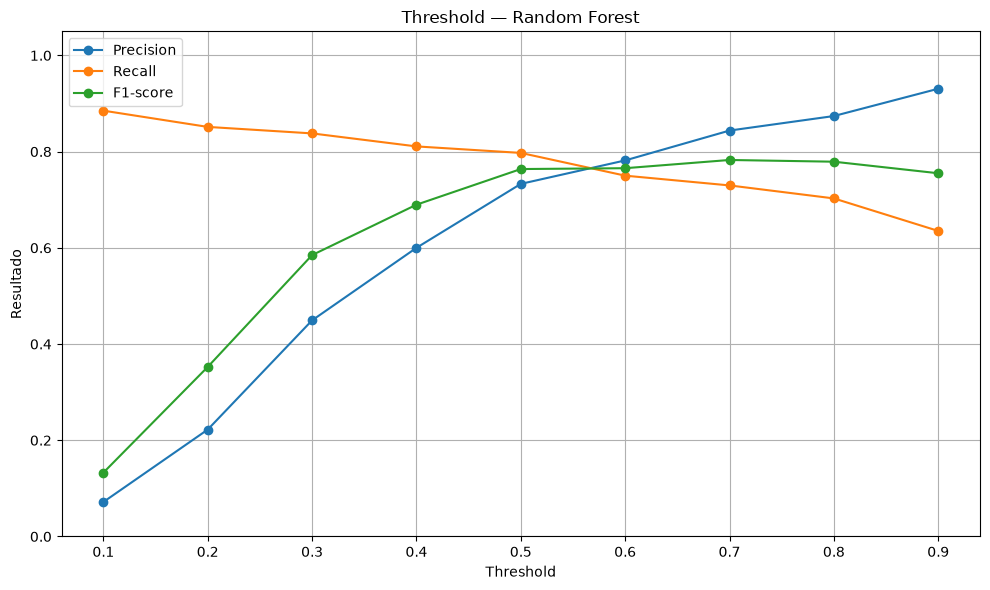

In [50]:
thresholds_rf.set_index("Threshold")[
    ["Precision", "Recall", "F1-score"]
].plot(
    figsize=(10, 6),
    marker="o",
)

plt.title("Threshold — Random Forest")
plt.xlabel("Threshold")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
best_rf_threshold = thresholds_rf.loc[
    thresholds_rf["F1-score"].idxmax()
]

best_rf_threshold

Threshold    0.700000
Precision    0.843750
Recall       0.729730
F1-score     0.782609
Name: 6, dtype: float64

In [52]:
thresholds_xgb = evaluate_thresholds(
    y_true=y_test,
    probabilities=probabilities["XGBoost"],
)

thresholds_xgb

,Threshold,Precision,Recall,F1-score
0,0.1,0.216123,0.851351,0.344733
1,0.2,0.345304,0.844595,0.490196
2,0.3,0.473282,0.837838,0.604878
3,0.4,0.510373,0.831081,0.632391
4,0.5,0.583732,0.824324,0.683473
5,0.6,0.662921,0.797297,0.723926
6,0.7,0.704819,0.790541,0.745223
7,0.8,0.758170,0.783784,0.770764
8,0.9,0.815603,0.777027,0.795848


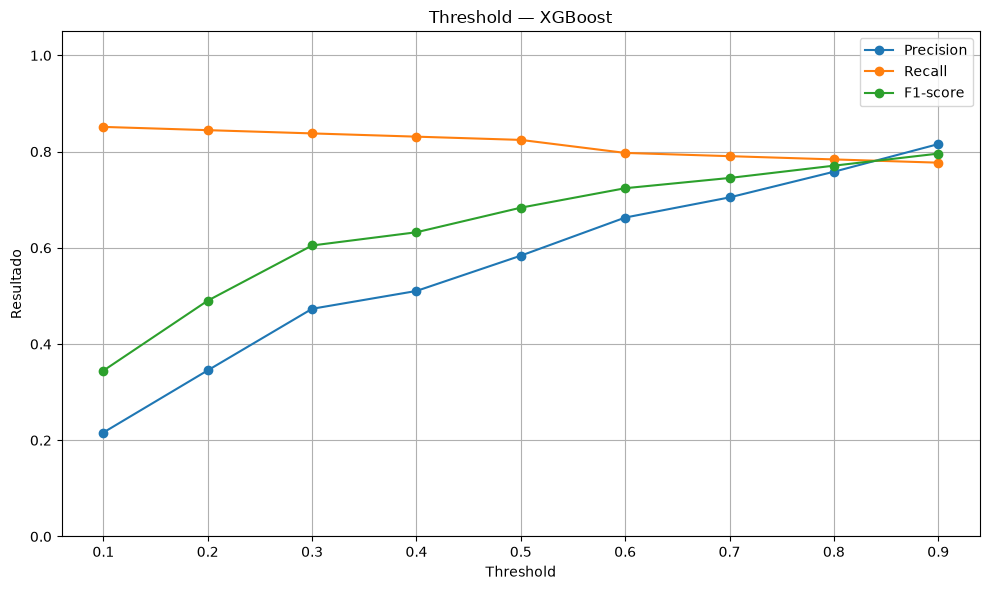

In [53]:
thresholds_xgb.set_index("Threshold")[
    ["Precision", "Recall", "F1-score"]
].plot(
    figsize=(10, 6),
    marker="o",
)

plt.title("Threshold — XGBoost")
plt.xlabel("Threshold")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
best_xgb_threshold = thresholds_xgb.loc[
    thresholds_xgb["F1-score"].idxmax()
]

best_xgb_threshold

Threshold    0.900000
Precision    0.815603
Recall       0.777027
F1-score     0.795848
Name: 8, dtype: float64

# Conclusão da Modelagem

Os três modelos apresentaram comportamentos diferentes:

- A **Regressão Logística** alcançou o maior Recall no threshold padrão, mas gerou muitos falsos positivos devido à baixa Precision.
- O **XGBoost** apresentou a maior PR-AUC, demonstrando boa capacidade de classificação em diferentes thresholds.
- O **Random Forest** apresentou o melhor equilíbrio geral no threshold padrão, com maior Precision, F1-score e ROC-AUC.

Durante a otimização do threshold do Random Forest, o valor `0.70` apresentou o maior F1-score:

- Precision: aproximadamente **84,38%**
- Recall: aproximadamente **72,97%**
- F1-score: aproximadamente **78,26%**

A escolha final do modelo e do threshold depende do objetivo do negócio:

- Para detectar o maior número possível de fraudes, deve-se priorizar Recall.
- Para evitar bloqueios indevidos, deve-se priorizar Precision.
- Para equilibrar os dois objetivos, pode-se utilizar o F1-score.

Com base nos resultados atuais, o Random Forest apresenta o melhor equilíbrio geral para esta versão do projeto.